
Prima simulazione di ROM con problema fdm 1D e generazione di calore interna.



Inserire la lunghezza della barra da simulare:  3
Inserire il numero di nodi che si vuole simulare:  500
Inserire il timestep da simulare:  10
Inserire il numero di step da simulare:  2000


Computational time for FOM with parametric sweep was: 263.65430188179016 s


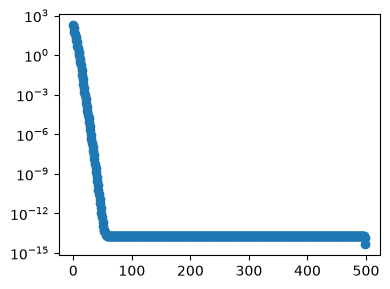

Scegli l'ordine r del tuo nuovo modello ridotto:  50


Computational time for ROM with parametric sweep was: 0.8765168190002441 s


In [1]:
import numpy as np
from scipy.sparse import diags
import matplotlib.pyplot as plt
import time

print("\nPrima simulazione di ROM con problema fdm 1D e generazione di calore interna.\n")
L = int(input("Inserire la lunghezza della barra da simulare: "))
n = int(input("Inserire il numero di nodi che si vuole simulare: ")) #2000
dt = int(input("Inserire il timestep da simulare: "))
n_steps = int(input("Inserire il numero di step da simulare: "))

dx = L / n # spessore di una discretizzazione
time_series = np.linspace(0, n_steps * dt, n_steps + 1)

# thermal properties
k_list = [10, 100, 1000] # W / m K
rho = 2700 # kg / m3
cp = 900 # J / kg K

# my input
omega_list = [0.001, 0.01, 0.1]
fg = lambda t, omega: 1e5 * np.sin(omega * t)

x0 = 0 # condizione di partenza
x0_vec = np.full(n, x0, dtype = np.float64)
snap = np.zeros((n, (n_steps + 1) * len(k_list) * len(omega_list)), dtype = np.float64)

#sweep combo
k_matrix, omega_matrix = np.meshgrid(k_list, omega_list)

# building matrix
A_dict = {}
for k in k_list:
    d = np.full(n, ((rho * cp) / (dt) + (2 * k) / dx**2), dtype = np.float64)
    d_l = np.full(n-1, -k / dx**2, dtype = np.float64)
    d_u = d_l
    diagonals = [d, d_l, d_u]

    A_loc = diags(diagonals, [0, -1, 1]).toarray()
    A_loc[0, 1] *= 2
    A_loc[n-1,n-2] *= 2

    A_dict[k] = A_loc

tic1 = time.time()

for i, (k, omega) in enumerate(zip(k_matrix.flatten(), omega_matrix.flatten())):
    k_loc, omega_loc = k, omega
    snap_loc = np.zeros((n, n_steps+1))
    snap_loc[:, 0] = x0_vec

    for t in range(n_steps):
        q_gen = fg(time_series[t+1], omega_loc)
        b_vec = (rho*cp/dt) * snap_loc[:, t]
        b_vec[0] += q_gen
        snap_loc[:, t + 1] = np.linalg.solve(A_dict[k_loc], b_vec)

    snap[:, i * (n_steps + 1): (i+1) * (n_steps +1)] = snap_loc

toc1 = time.time()

print(f"Computational time for FOM with parametric sweep was: {toc1 - tic1} s")

U, sigma, Vt = np.linalg.svd(snap)

fig, ax = plt.subplots(figsize = (4,3))
plt.semilogy(sigma, marker = "o")
plt.tight_layout()
plt.show()
r = int(input("Scegli l'ordine r del tuo nuovo modello ridotto: "))
V = U[:,:r]
x_vec_r = np.zeros((r, (n_steps+1) * len(k_list) * len(omega_list)))

tic2 = time.time()

xr_0 = V.T @ snap[:, 0]

Ar_dict = {}

for k in k_list:
    Ar_dict[k] = V.T @ A_dict[k] @ V

for i, (k, omega) in enumerate(zip(k_matrix.flatten(), omega_matrix.flatten())):
    k_loc, omega_loc = k, omega
    xr_loc = np.zeros((r, n_steps + 1), dtype = np.float64)
    xr_loc[:, 0] = xr_0

    for t in range(n_steps):
        x_full = V @ xr_loc[:, t]
        q_gen = fg(time_series[t+1], omega_loc)
        b_vec = (rho*cp/dt) * x_full
        b_vec[0] += q_gen
        b_r = V.T @ b_vec
        xr_loc[:, t+1] = np.linalg.solve(Ar_dict[k_loc], b_r)

    x_vec_r[:, i * (n_steps + 1) : (i + 1) * (n_steps + 1)] = xr_loc

x_full_sweep = V @ x_vec_r

toc2 = time.time()

print(f"Computational time for ROM with parametric sweep was: {toc2-tic2} s")

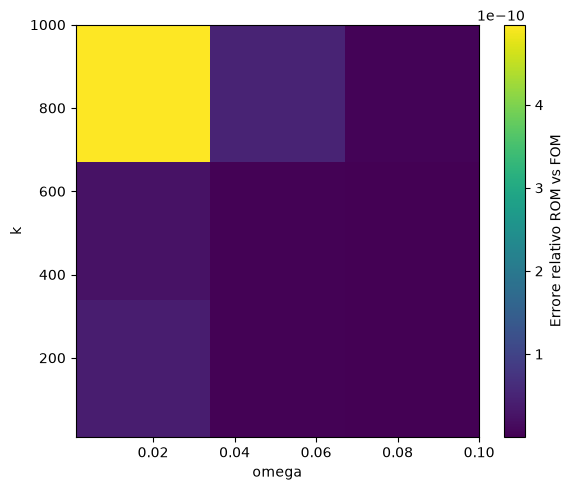

In [2]:
snap_rep = np.reshape(snap, (n, len(omega_list), len(k_list), n_steps + 1))
x_full_rep = np.reshape(x_full_sweep, (n, len(omega_list), len(k_list), n_steps + 1))
diff = snap_rep - x_full_rep
error_grid = np.linalg.norm(diff, axis=(0,3))

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(error_grid.T, aspect='auto', origin='lower',
               extent=[min(omega_list), max(omega_list), min(k_list), max(k_list)])
ax.set_xlabel("omega")
ax.set_ylabel("k")
plt.colorbar(im, label="Errore relativo ROM vs FOM")
plt.tight_layout()
plt.show()


In [6]:
%matplotlib widget

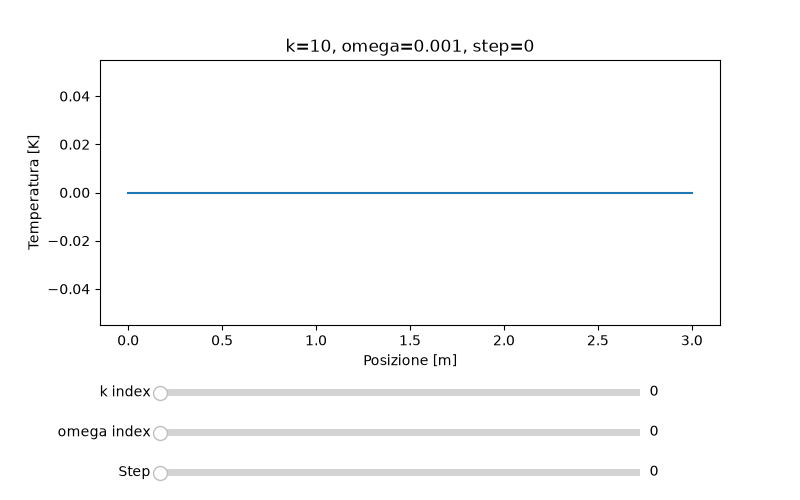

In [7]:
from matplotlib.widgets import Slider

fig, ax = plt.subplots(figsize=(8,5))
plt.subplots_adjust(bottom=0.35)

position = np.linspace(0, L, n)

line, = ax.plot(position, snap_rep[:, 0, 0, 0])
ax.set_xlabel("Posizione [m]")
ax.set_ylabel("Temperatura [K]")
ax.set_title(f"k={k_list[0]}, omega={omega_list[0]}, step=0")

ax_k = plt.axes([0.2, 0.2, 0.6, 0.03])
slider_k = Slider(ax_k, 'k index', 0, len(k_list)-1, valinit=0, valstep=1)

ax_omega = plt.axes([0.2, 0.12, 0.6, 0.03])
slider_omega = Slider(ax_omega, 'omega index', 0, len(omega_list)-1, valinit=0, valstep=1)

ax_time = plt.axes([0.2, 0.04, 0.6, 0.03])
slider_time = Slider(ax_time, 'Step', 0, n_steps, valinit=0, valstep=1)

def update(val):
    k_idx = int(slider_k.val)
    omega_idx = int(slider_omega.val)
    t_idx = int(slider_time.val)
    line.set_ydata(snap_rep[:, omega_idx, k_idx, t_idx])
    ax.set_title(f"k={k_list[k_idx]}, omega={omega_list[omega_idx]}, step={t_idx}")
    fig.canvas.draw_idle()

slider_k.on_changed(update)
slider_omega.on_changed(update)
slider_time.on_changed(update)
plt.show()